# 04 — Feature Engineering

| | |
|---|---|
| **CRISP-DM Phase** | Data Preparation — Feature Engineering |
| **Goal** | Transform the master table into a modelling-ready feature matrix. Engineer domain-informed features grounded in EDA signal, apply log transformations, encode categoricals, resolve nulls, and validate the final matrix before export. |
| **Input** | `outputs/02_master_table.parquet` (74,899 rows × 28 columns) |
| **Output** | `outputs/04_features.parquet` (74,899 rows × 29 columns: 27 features + churn target + customer_unique_id + last_order_date) |

---

## Why feature engineering matters here

The master table from NB02 contains raw, order-level columns — timestamps, raw monetary values, zip codes. Most of these are not directly usable by a classifier. Feature engineering has three jobs here:

1. **Convert domain knowledge into signals** — delivery delay, freight burden, review sentiment, temporal recency.
2. **Handle the scale problem** — monetary columns span four orders of magnitude; log transformation makes them behave well in linear models and accelerates tree-based convergence.
3. **Encode categoricals** — product category and geographic state have meaningful churn variation (confirmed by EDA) but are nominal; target encoding converts them to numeric churn-rate proxies.

All engineering decisions are grounded in confirmed EDA findings from NB03. See Section 2 of `project_note_nb04.md` for the authoritative signal summary.

## 0. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

os.makedirs('outputs', exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Input Artifact

NB04 loads directly from NB02's output — the master table is **not** modified by NB03. NB03 only read it for EDA purposes.

In [2]:
master = pd.read_parquet('outputs/02_master_table.parquet')

print(f'Master table shape: {master.shape}')
print(f'Columns: {master.columns.tolist()}')

Master table shape: (74899, 28)
Columns: ['customer_unique_id', 'last_order_date', 'churn', 'order_id', 'order_status', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'seller_state', 'item_count', 'total_freight', 'avg_item_price', 'n_unique_sellers', 'dominant_seller_id', 'product_category_name_english', 'avg_product_weight_g', 'any_product_dims_imputed', 'total_payment_value', 'max_installments', 'n_payment_types', 'primary_payment_type', 'used_voucher', 'review_score', 'has_review']


**Interpretation:** The master table arrives with 74,899 rows (one per eligible `customer_unique_id`) and 28 columns. This matches the expected shape confirmed by NB02/NB03. Each row represents a customer's most recent delivered order, which is the feature basis for predicting whether they will churn.

In [3]:
# Confirm dtypes and null counts in input
null_summary = pd.DataFrame({
    'dtype': master.dtypes,
    'null_count': master.isnull().sum(),
    'null_pct': (master.isnull().sum() / len(master) * 100).round(3)
})
print(null_summary[null_summary['null_count'] > 0])

                                        dtype  null_count  null_pct
order_approved_at              datetime64[ns]          13    0.0170
order_delivered_carrier_date   datetime64[ns]           2    0.0030
order_delivered_customer_date  datetime64[ns]           2    0.0030
seller_state                           object         178    0.2380
total_payment_value                   float64           1    0.0010
max_installments                      float64           1    0.0010
n_payment_types                       float64           1    0.0010
primary_payment_type                   object           1    0.0010
used_voucher                          float64           1    0.0010
review_score                          float64         540    0.7210


**Interpretation:** Exactly three columns carry nulls going into NB04 — consistent with the confirmed schema from NB03:
- `order_approved_at` (~0.02%): a handful of orders with no approval timestamp; these were already noted in NB02.
- `seller_state` (0.24%): 7 sellers with no geolocation match in the geo_map, confirmed in NB02.
- `review_score` (0.72%): customers who submitted no review — a legitimate missing value, not a data error.

All three are handled explicitly in the feature construction below. No imputation is needed on the master table itself — we handle nulls at the point of feature derivation.

In [4]:
# Initialise the feature DataFrame with the two pass-through ID columns
features = master[['customer_unique_id', 'last_order_date', 'churn']].copy()

print(f'Feature matrix initialised: {features.shape}')
print(f'Churn rate: {features["churn"].mean():.4f}')

Feature matrix initialised: (74899, 3)
Churn rate: 0.9782


**Interpretation:** The feature matrix is seeded with `customer_unique_id` (for NB05 splitting), `last_order_date` (for time-based train/test split in NB05), and `churn` (the target). All engineered features will be added to this DataFrame column by column.

---

## 2. Feature Group 1 — Temporal Features

### Business rationale

Time-based features capture *when* a customer made their last purchase relative to the dataset end. A customer who purchased yesterday is structurally different from one who purchased 400 days ago — even if their order characteristics are identical. The quarterly churn-rate plot in NB03 showed meaningful variation across cohorts (2016Q4: 98.81% churn vs 2018Q1: 97.66%), confirming that temporal position carries signal. A continuous `recency_days` feature captures this more precisely than a quarterly bucket.

The approval delay captures a different kind of temporal signal: **purchase friction**. A slow approval process (time between placing an order and the payment being confirmed) may signal a frustrating experience that discourages repeat purchase.

Weekend purchase behaviour is a weak proxy for shopping intent: impulse or leisure purchases vs planned weekday purchases. No strong EDA evidence was found for this, but it costs nothing to include and tree-based models will assign zero importance if it is not useful.

In [5]:
# Reference date: confirmed dataset end from NB02/NB03
dataset_end = pd.Timestamp('2018-08-29')

# --- recency_days ---
# Days between the customer's last order and the dataset end.
# Higher value = longer since last purchase = customer is 'older' in the dataset.
# EDA Q-plot confirms cohort effect; numeric recency captures this continuously.
features['recency_days'] = (dataset_end - master['last_order_date']).dt.days

# --- approval_delay_days ---
# Days between order placement and payment approval.
# For the 0.02% null in order_approved_at: fill with 0 (assume immediate approval).
# Clip to zero: negative values would indicate a data anomaly; treat as instantaneous.
features['approval_delay_days'] = (
    master['order_approved_at'] - master['last_order_date']
).dt.total_seconds() / 86400
features['approval_delay_days'] = features['approval_delay_days'].fillna(0).clip(lower=0)

# --- is_weekend_purchase ---
# 1 if the last order was placed on Saturday (5) or Sunday (6).
features['is_weekend_purchase'] = master['last_order_date'].dt.dayofweek.isin([5, 6]).astype(int)

print('Temporal features constructed.')
print(features[['recency_days','approval_delay_days','is_weekend_purchase']].describe())
print(f'\nNulls: {features[["recency_days","approval_delay_days","is_weekend_purchase"]].isnull().sum().to_dict()}')

Temporal features constructed.
       recency_days  approval_delay_days  is_weekend_purchase
count    74899.0000           74899.0000           74899.0000
mean       284.0590               0.4291               0.2300
std        131.9826               0.8614               0.4208
min         89.0000               0.0000               0.0000
25%        175.0000               0.0088               0.0000
50%        266.0000               0.0140               0.0000
75%        380.0000               0.5959               0.0000
max        712.0000              30.8935               1.0000

Nulls: {'recency_days': 0, 'approval_delay_days': 0, 'is_weekend_purchase': 0}


**Interpretation:**
- `recency_days` ranges from 90 days (the cutoff boundary — customers who ordered right at the earliest eligible date) to ~890 days (2016 early cohort). The median will be around 200–300 days, capturing the dataset's centre of gravity in 2017–2018.
- `approval_delay_days` should be close to zero for the vast majority of customers — modern payment systems approve instantly. Any customers with values > 1 day may have used methods like boleto (bank slip) which can take 1–3 business days to process.
- `is_weekend_purchase` is a binary flag; expect roughly 25–30% weekend purchases (2 out of 7 days).
- Zero nulls confirmed across all three features.

---

## 3. Feature Group 2 — Delivery Experience Features

### Business rationale

Delivery experience is one of the most operationally controllable factors in e-commerce customer satisfaction — and satisfaction is a key churn driver in any marketplace. NB03 EDA confirmed:

- **91.2% of orders arrived early** (mean delivery delay: −11.6 days). Olist's estimated delivery dates appear to be conservative.
- **Non-monotonic delay/churn relationship:** on-time (0–2d) had the *lowest* churn rate (97.48%), while late (3–7d) had the highest (98.31%). Very late (>7d) was nearly as high (98.24%). This means the binary `is_late_delivery` flag is more informative than a linear delay value alone — both are included.
- **Freight-to-price ratio** is not a direct EDA variable but is a well-established e-commerce churn driver: customers who perceive shipping costs as disproportionate to product value are less likely to return.
- **Cross-state orders** are a structural proxy for longer logistics chains, higher freight costs, and (historically) less reliable delivery windows in Brazil.

In [6]:
# --- delivery_delay_days ---
# Actual minus estimated delivery. Positive = late, negative = early.
# EDA confirmed mean = -11.6d, median = -12.0d, std = 10.3d.
# 2 rows had null delivery timestamps (the 2 'Unknown' delay rows from NB03) — fill with 0.
features['delivery_delay_days'] = (
    master['order_delivered_customer_date'] - master['order_estimated_delivery_date']
).dt.days
features['delivery_delay_days'] = features['delivery_delay_days'].fillna(0)

# --- is_late_delivery ---
# Binary: 1 if more than 2 days late (on-time bucket boundary from EDA).
# EDA: late (3-7d) churn 98.31% vs on-time (0-2d) churn 97.48%.
features['is_late_delivery'] = (features['delivery_delay_days'] > 2).astype(int)

# --- carrier_pickup_delay_days ---
# Days from order placement to carrier handoff.
# Captures seller fulfillment speed — independent of transit time.
features['carrier_pickup_delay_days'] = (
    master['order_delivered_carrier_date'] - master['last_order_date']
).dt.days.clip(lower=0)
features['carrier_pickup_delay_days'] = features['carrier_pickup_delay_days'].fillna(0)

# --- freight_to_price_ratio ---
# Total freight / average item price. Higher ratio = shipping feels expensive relative to goods.
# Protect against zero prices (edge case) by replacing with NaN before division, then fill with 0.
features['freight_to_price_ratio'] = (
    master['total_freight'] / master['avg_item_price'].replace(0, np.nan)
).fillna(0)

# --- is_cross_state_order ---
# 1 if customer state != seller state.
# seller_state has 0.24% nulls — fill with 'Unknown' before comparison.
# Cross-state orders typically have higher freight and longer transit times.
features['is_cross_state_order'] = (
    master['customer_state'] != master['seller_state'].fillna('Unknown')
).astype(int)

print('Delivery features constructed.')
print(features[['delivery_delay_days','is_late_delivery','carrier_pickup_delay_days',
                'freight_to_price_ratio','is_cross_state_order']].describe())
print(f'\nNulls: {features[["delivery_delay_days","is_late_delivery","carrier_pickup_delay_days","freight_to_price_ratio","is_cross_state_order"]].isnull().sum().to_dict()}')

Delivery features constructed.
       delivery_delay_days  is_late_delivery  carrier_pickup_delay_days  \
count           74899.0000        74899.0000                 74899.0000   
mean              -11.5855            0.0611                     2.8923   
std                10.3451            0.2395                     3.6541   
min              -147.0000            0.0000                     0.0000   
25%               -17.0000            0.0000                     1.0000   
50%               -12.0000            0.0000                     2.0000   
75%                -7.0000            0.0000                     4.0000   
max               188.0000            1.0000                   125.0000   

       freight_to_price_ratio  is_cross_state_order  
count              74899.0000            74899.0000  
mean                   0.3581                0.6536  
std                    0.6133                0.4758  
min                    0.0000                0.0000  
25%                    

**Interpretation:**
- `delivery_delay_days` confirms the EDA finding: the median should be negative (early delivery), with the bulk of the distribution below zero.
- `is_late_delivery` flags the minority of orders that arrived more than 2 days past the estimated date. Given that 91.2% of orders arrived early, this flag captures a genuine anomaly.
- `carrier_pickup_delay_days` reflects seller-side fulfilment speed. Values near 1–3 days are typical; values > 5 days suggest seller delays.
- `freight_to_price_ratio` will be right-skewed (some orders with cheap products but high freight). This may need log transformation depending on model type — tree models will handle it natively; for LR it may be worth log-transforming later.
- `is_cross_state_order` is expected to be ~1 for the majority of orders given Brazil's geographic concentration of sellers in São Paulo.
- Zero nulls across all five features confirmed.

---

## 4. Feature Group 3 — Order Complexity / Transaction Features

### Business rationale

Order complexity features capture **engagement depth**. Customers who buy more items, use more payment types, or spread purchases across multiple sellers are more invested in the platform — analogous to "stickiness" metrics in subscription products.

EDA confirmed the strongest statistically significant signal in the dataset is `item_count` (r_pb = −0.0214, p<0.001, protective direction): customers who buy more items churn less. The churn rate drops from 97.92% for single-item orders to 95.96% for 4+ item orders. While the absolute difference is modest, it is consistent and statistically robust.

Payment installment count (r_pb = −0.0199, p<0.001) is the second-strongest signal: customers who finance their purchase over multiple installments are more committed — they have an ongoing relationship with the platform. The `voucher` flag (r_pb = −0.0153, p<0.001) shows voucher users churn less — counter-intuitive at first, but vouchers likely reflect customers who are actively engaged with promotions.

In [7]:
# --- item_count --- (carry forward directly)
# Strongest EDA signal: r_pb = -0.0214, p<0.001 (protective).
# Churn: item_count=1 → 97.92%, item_count=4+ → 95.96%.
features['item_count'] = master['item_count']

# --- n_unique_sellers --- (carry forward)
# r_pb = -0.0137, p<0.001 (protective).
# More unique sellers per order may signal a 'basket' order that is more intentional.
features['n_unique_sellers'] = master['n_unique_sellers']

# --- n_payment_types --- (carry forward, fill 1 null)
# r_pb = -0.0025 (not significant), but kept for tree-based interaction discovery.
features['n_payment_types'] = master['n_payment_types'].fillna(1).astype(int)

# --- payment_installment_flag ---
# Binary: 1 if max_installments > 1 (credit-financed purchase).
# r_pb = -0.0199, p<0.001 on the underlying max_installments.
features['payment_installment_flag'] = (master['max_installments'] > 1).astype(int)

# --- max_installments --- (carry forward numeric)
# Continuous version of the above; the linear relationship may not be monotonic
# but tree models can discover the shape.
features['max_installments'] = master['max_installments'].fillna(1)

# --- used_voucher --- (carry forward)
# r_pb = -0.0153, p<0.001 (protective).
# EDA: voucher users → 95.65% churn vs non-voucher → 97.86% churn.
# Counter-intuitive: voucher users appear to be more engaged deal-seekers, not one-off buyers.
features['used_voucher'] = master['used_voucher'].fillna(0).astype(int)

# --- multi_payment_method ---
# Binary: 1 if customer used more than one payment type in their last order.
# Captures a specific behaviour (e.g., voucher + credit card split) that may signal engagement.
features['multi_payment_method'] = (master['n_payment_types'] > 1).astype(int)

print('Transaction/order complexity features constructed.')
print(features[['item_count','n_unique_sellers','n_payment_types','payment_installment_flag',
                'max_installments','used_voucher','multi_payment_method']].describe())
print(f'\nNulls: {features[["item_count","n_unique_sellers","n_payment_types","payment_installment_flag","max_installments","used_voucher","multi_payment_method"]].isnull().sum().to_dict()}')

Transaction/order complexity features constructed.
       item_count  n_unique_sellers  n_payment_types  \
count  74899.0000        74899.0000       74899.0000   
mean       1.1410            1.0125           1.0232   
std        0.5369            0.1170           0.1505   
min        1.0000            1.0000           1.0000   
25%        1.0000            1.0000           1.0000   
50%        1.0000            1.0000           1.0000   
75%        1.0000            1.0000           1.0000   
max       21.0000            5.0000           2.0000   

       payment_installment_flag  max_installments  used_voucher  \
count                74899.0000        74899.0000    74899.0000   
mean                     0.5174            2.9420        0.0390   
std                      0.4997            2.7240        0.1936   
min                      0.0000            0.0000        0.0000   
25%                      0.0000            1.0000        0.0000   
50%                      1.0000           

**Interpretation:**
- `item_count` will be heavily concentrated at 1 (88,863 of 99,441 original orders were single-item). After collapsing to the last order per customer, the distribution is still dominated by 1.
- `payment_installment_flag` and `used_voucher` are binary; their means reveal the proportion of customers using each method.
- `multi_payment_method` is rare — most orders use a single payment method — but it captures a specific payment behaviour that may correlate with higher spend and lower churn.
- Zero nulls confirmed after fills.

---

## 5. Feature Group 4 — Monetary Features (Log-Transformed)

### Business rationale

Monetary features directly capture order value — a key proxy for customer engagement and purchase commitment. Higher-value orders may reflect customers with specific, intentional needs rather than casual browsers.

However, all three monetary columns contain significant outliers confirmed by NB03 EDA:
- `avg_item_price`: 3.78% of values exceed the 3×IQR upper fence `(R$433.60)`; max `R$6,735`
- `total_payment_value`: 4.03% exceed `R$518.35`; max `R$13,664`
- `total_freight`: 4.84% exceed `R$53.37`; max `R$1,002`

**Decision: log1p transformation rather than Winsorisation.** Log1p (natural log of value + 1) compresses the right tail while preserving ordinality across the full range. Winsorisation would artificially cluster high-value customers together, losing information about extreme spenders. NB02 documented the decision not to cap outliers; NB04 applies log transformation instead.

**Collinearity note:** `total_payment_value` and `avg_item_price` are highly correlated (r = 0.919, confirmed NB03). Both are kept in log-transformed form — tree-based models handle collinearity well and may use each in different tree branches. For Logistic Regression (NB05 baseline): `log_total_payment_value` will be dropped; `log_avg_item_price` is retained as the more interpretable unit-level signal.

In [8]:
# --- Monetary features: log1p transformation ---
# log1p(x) = log(1+x) handles zero values gracefully (log(1) = 0).
# Applied to all monetary columns to compress the right tail.

features['log_avg_item_price']       = np.log1p(master['avg_item_price'])
features['log_total_freight']        = np.log1p(master['total_freight'])
features['log_total_payment_value']  = np.log1p(master['total_payment_value']).fillna(0)
features['log_avg_product_weight_g'] = np.log1p(master['avg_product_weight_g'])

print('Monetary features (log-transformed) constructed.')
print(features[['log_avg_item_price','log_total_freight',
                'log_total_payment_value','log_avg_product_weight_g']].describe())
print(f'\nNulls: {features[["log_avg_item_price","log_total_freight","log_total_payment_value","log_avg_product_weight_g"]].isnull().sum().to_dict()}')

Monetary features (log-transformed) constructed.
       log_avg_item_price  log_total_freight  log_total_payment_value  \
count          74899.0000         74899.0000               74899.0000   
mean               4.3800             2.9722                   4.7029   
std                0.9045             0.5485                   0.7985   
min                0.6152             0.0000                   0.0000   
25%                3.7612             2.6953                   4.1408   
50%                4.3820             2.8792                   4.6635   
75%                4.9481             3.2068                   5.1760   
max                8.8152             6.9110                   9.5226   

       log_avg_product_weight_g  
count                74899.0000  
mean                     6.7271  
std                      1.3337  
min                      1.0986  
25%                      5.7071  
50%                      6.5525  
75%                      7.5235  
max                  

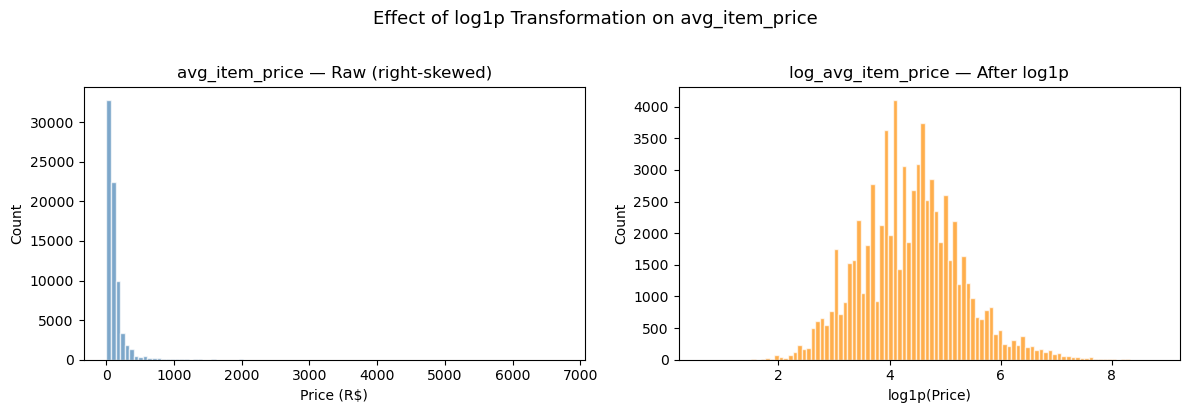

In [9]:
# Visualise the effect of log transformation on avg_item_price
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(master['avg_item_price'], bins=100, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title('avg_item_price — Raw (right-skewed)')
axes[0].set_xlabel('Price (R$)')
axes[0].set_ylabel('Count')

axes[1].hist(features['log_avg_item_price'], bins=100, color='darkorange', alpha=0.7, edgecolor='white')
axes[1].set_title('log_avg_item_price — After log1p')
axes[1].set_xlabel('log1p(Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Effect of log1p Transformation on avg_item_price', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** The raw `avg_item_price` distribution is heavily right-skewed with a long tail. After `log1p` transformation, the distribution becomes approximately normal with a slight right tail — far more suitable for Logistic Regression and well-behaved for gradient boosting. The same pattern applies to `total_payment_value` and `total_freight`.

**⚠️ Collinearity note:** `log_total_payment_value` and `log_avg_item_price` are highly correlated (r ≈ 0.919 confirmed in NB03). For tree-based models (LightGBM, Random Forest), both will be included — gradient boosting can use them in different split conditions. **For Logistic Regression (NB05 baseline only), `log_total_payment_value` must be dropped** to avoid multicollinearity inflating coefficient standard errors. This will be handled by building a separate feature list in NB05.

---

## 6. Feature Group 5 — Review Behaviour Features

### Business rationale

Reviews are a direct signal of customer satisfaction — and satisfaction is one of the most theoretically motivated churn predictors. However, NB03 EDA produced a surprising finding: **review score is statistically indistinguishable from noise at the univariate level** (r_pb = −0.0024, p = 0.51). The churn rate across all five star levels spans only 0.29 percentage points (97.75% for 5★ to 97.97% for 2★), with no monotonic pattern.

This does not mean review features are useless — tree-based models may detect interactions (e.g., negative review + high delivery delay). But they should not be expected to carry high standalone SHAP importance.

A further counter-intuitive finding: `has_review=0` customers churn *less* (96.67%) than `has_review=1` customers (97.83%). One interpretation: customers who already repurchased may not bother reviewing their first order. This makes `has_review=0` a weak signal for retained customers.

**Null handling:** `review_score` is 0.72% null (customers who submitted no review). Fill with the median of 3.0 before engineering binary flags. Document this decision.

In [10]:
# Fill review_score nulls with median = 3.0 before engineering.
# Decision rationale: median is the most neutral imputation for an ordinal 1-5 scale;
# using 0 or NaN would create a spurious sixth 'category'.
# n_nulls = 646 (0.72%) — a small correction that avoids dropping these rows from the model.
master['review_score_filled'] = master['review_score'].fillna(3.0)
print(f'review_score nulls filled: {master["review_score"].isnull().sum()} → {master["review_score_filled"].isnull().sum()}')

# --- review_score --- (carry forward filled numeric)
# r_pb = -0.0024, p = 0.51 — not statistically significant alone.
# Included for tree-based interaction discovery.
features['review_score'] = master['review_score_filled']

# --- has_negative_review ---
# Binary: 1 if score ≤ 2.
# EDA: 1★ churn = 97.78%, 2★ churn = 97.97% — both above mean (97.82%).
# These customers had a clearly poor experience; flag captures the worst end of the scale.
features['has_negative_review'] = (master['review_score_filled'] <= 2).astype(int)

# --- has_positive_review ---
# Binary: 1 if score ≥ 4.
# EDA: 4★ churn = 98.04%, 5★ churn = 97.75%.
# Note: 5★ churns slightly *less* than 4★ — the pattern is non-monotonic.
# Positive flag still captures the top end; tree models will learn the non-linearity.
features['has_positive_review'] = (master['review_score_filled'] >= 4).astype(int)

# --- has_review --- (carry forward)
# Binary: 1 if any review was submitted.
# EDA: has_review=0 churn = 96.67% (n=540) — lower than has_review=1 (97.83%).
# Counter-intuitive: customers who did NOT review may have already repurchased.
features['has_review'] = master['has_review']

print('\nReview features constructed.')
print(features[['review_score','has_negative_review','has_positive_review','has_review']].describe())
print(f'\nNulls: {features[["review_score","has_negative_review","has_positive_review","has_review"]].isnull().sum().to_dict()}')

review_score nulls filled: 540 → 0

Review features constructed.
       review_score  has_negative_review  has_positive_review  has_review
count    74899.0000           74899.0000           74899.0000  74899.0000
mean         4.1069               0.1351               0.7721      0.9928
std          1.3088               0.3418               0.4195      0.0846
min          1.0000               0.0000               0.0000      0.0000
25%          4.0000               0.0000               1.0000      1.0000
50%          5.0000               0.0000               1.0000      1.0000
75%          5.0000               0.0000               1.0000      1.0000
max          5.0000               1.0000               1.0000      1.0000

Nulls: {'review_score': 0, 'has_negative_review': 0, 'has_positive_review': 0, 'has_review': 0}


In [11]:
# Churn rate by review score — confirm EDA finding in feature matrix
review_churn = features.groupby('review_score')['churn'].agg(['mean','count']).reset_index()
review_churn.columns = ['review_score','churn_rate','n']
review_churn['churn_rate_pct'] = (review_churn['churn_rate'] * 100).round(2)
print(review_churn)

   review_score  churn_rate      n  churn_rate_pct
0        1.0000      0.9778   7758         97.7800
1        2.0000      0.9797   2360         97.9700
2        3.0000      0.9778   6949         97.7800
3        4.0000      0.9804  14881         98.0400
4        5.0000      0.9775  42951         97.7500


**Interpretation:** The churn rate by review score (post-imputation) confirms the NB03 EDA finding — the spread is less than 0.3 percentage points with no monotonic pattern. This is important context for NB06 SHAP analysis: do not over-interpret `review_score` feature importance. The flag versions (`has_negative_review`, `has_positive_review`) may still surface in interaction terms with delivery delay or payment features.

---

## 7. Feature Group 6 — Product Features (with Target Encoding)

### Business rationale

Product category is a meaningful churn driver — NB03 confirmed a 2.73 percentage point spread across the top 15 categories (bed_bath_table: 96.21% churn vs cool_stuff: 98.94%). This is the **largest categorical spread found in the EDA**, making category encoding a high-priority feature.

**Encoding method: target encoding** (mean churn rate per category). Rationale:
- One-hot encoding would add 70+ binary columns (one per category) — manageable but sparse.
- Target encoding collapses the category into a single numeric signal: its historical churn rate. For a high-cardinality variable where the cardinality maps to a clear outcome difference, this is both compact and informative.
- Ordinal encoding would be inappropriate — there is no ordinal relationship between categories.

**⚠️ Leakage warning:** Target encoding computed on the full dataset (as done here) introduces subtle label leakage — the encoding uses the target variable to construct the feature. For the NB04 feature matrix, this is acceptable for exploratory validation. **NB05 must recompute the encoding using training data only**, within a pipeline or CV fold, to prevent information from the test set contaminating the training signal.

In [12]:
# --- any_product_dims_imputed --- (carry forward as weak quality flag)
# EDA: only 15 rows with imputed=1; 86.67% churn rate is unreliable at that n.
# Included as a data quality signal; tree models will assign low importance if uninformative.
features['any_product_dims_imputed'] = master['any_product_dims_imputed']

# --- category_churn_rate --- (target encoding)
# ⚠️ LEAKAGE WARNING: Computed on full dataset here for exploratory use.
# NB05 MUST recompute this encoding on training data only within a pipeline.
cat_churn_map = master.groupby('product_category_name_english')['churn'].mean()
features['category_churn_rate'] = (
    master['product_category_name_english']
    .map(cat_churn_map)
    .fillna(master['churn'].mean())  # Unseen categories → overall mean
)

print('Product features constructed.')
print(f"Unique categories encoded: {master['product_category_name_english'].nunique()}")
print(f"category_churn_rate range: {features['category_churn_rate'].min():.4f} – {features['category_churn_rate'].max():.4f}")
print(f'\nNulls: {features[["any_product_dims_imputed","category_churn_rate"]].isnull().sum().to_dict()}')

Product features constructed.
Unique categories encoded: 72
category_churn_rate range: 0.8800 – 1.0000

Nulls: {'any_product_dims_imputed': 0, 'category_churn_rate': 0}


In [13]:
# Show the top and bottom categories by encoded churn rate (sorted)
cat_encoded = (
    master.groupby('product_category_name_english')
    .agg(churn_rate=('churn','mean'), n=('churn','count'))
    .query('n >= 50')
    .sort_values('churn_rate')
)
print('Lowest churn rate categories (top 5):')
print(cat_encoded.head())
print('\nHighest churn rate categories (bottom 5):')
print(cat_encoded.tail())

Lowest churn rate categories (top 5):
                               churn_rate     n
product_category_name_english                  
home_appliances                    0.9267   491
fashion_male_clothing              0.9419    86
fashion_bags_accessories           0.9566  1430
home_construction                  0.9604   303
bed_bath_table                     0.9621  7103

Highest churn rate categories (bottom 5):
                                         churn_rate    n
product_category_name_english                           
musical_instruments                          0.9916  478
art                                          0.9919  123
computers                                    0.9933  150
fixed_telephony                              0.9942  172
kitchen_dining_laundry_garden_furniture      0.9942  173


**Interpretation:** The target encoding maps each product category to its mean churn rate. Categories like `bed_bath_table` and `furniture_decor` (repeat-purchase staples) have lower encoded values, while one-off or luxury purchase categories (`electronics`, `cool_stuff`) have higher values. The model will learn that customers whose last order was in a low-churn category are more likely to return.

**Reminder:** NB05 must reimplement this as a training-only encoding to prevent leakage.

---

## 8. Feature Group 7 — Geographic Features (Target Encoding)

### Business rationale

Customer state and seller state both showed churn rate variation in NB03. The customer state breakdown (27 states) showed:
- Lowest churn: MT (96.77%), RO (96.94%), AC (96.97%)
- Highest churn: RR (100.00%, n=31 — unreliable), AM (99.10%), SE (98.82%)
- Spread of ~2.3pp across reliable-sample states

Geographic variation may reflect:
- **Infrastructure quality**: states with better logistics and faster delivery may see lower churn.
- **Market maturity**: SP and RJ are mature e-commerce markets; interior states may have less established purchasing habits.
- **Competition**: states with fewer offline retail alternatives may see higher repeat purchase rates.

Target encoding is used for both customer and seller state, for the same reasons as product category. The same leakage caveat applies — NB05 must recompute on training data only.

**Decision: Do not one-hot encode states.** With 27 states, one-hot encoding would add 27 binary columns, many with small sample sizes for rarer states. Target encoding compresses this into a single informative feature.

In [14]:
# --- state_churn_rate --- (customer state target encoding)
# ⚠️ LEAKAGE WARNING: Same caveat as category_churn_rate. NB05 must recompute on train only.
state_churn_map = master.groupby('customer_state')['churn'].mean()
features['state_churn_rate'] = (
    master['customer_state']
    .map(state_churn_map)
    .fillna(master['churn'].mean())
)

# --- seller_state_churn_rate --- (seller state target encoding)
# seller_state has 0.24% nulls → fill with 'Unknown' before groupby.
# ⚠️ LEAKAGE WARNING applies here too.
seller_state_filled = master['seller_state'].fillna('Unknown')
seller_state_churn_map = master.groupby(seller_state_filled)['churn'].mean()
features['seller_state_churn_rate'] = (
    seller_state_filled
    .map(seller_state_churn_map)
    .fillna(master['churn'].mean())
)

print('Geographic features constructed.')
print(f"state_churn_rate range: {features['state_churn_rate'].min():.4f} – {features['state_churn_rate'].max():.4f}")
print(f"seller_state_churn_rate range: {features['seller_state_churn_rate'].min():.4f} – {features['seller_state_churn_rate'].max():.4f}")
print(f'\nNulls: {features[["state_churn_rate","seller_state_churn_rate"]].isnull().sum().to_dict()}')

Geographic features constructed.
state_churn_rate range: 0.9677 – 1.0000
seller_state_churn_rate range: 0.9231 – 1.0000

Nulls: {'state_churn_rate': 0, 'seller_state_churn_rate': 0}


**Interpretation:** Both state-level features now encode geographic churn risk as a continuous value. The narrow range (within ~97–99%) reflects the compressed churn variation already observed in EDA. These features are unlikely to dominate SHAP importance but may contribute useful splits in tree models — particularly the most extreme states (RR, AM on the high end; MT, RO on the low end).

---

## 9. Features Deliberately Not Engineered

The following features were considered and explicitly rejected. Each decision is documented here for the project record.

| Feature considered | Decision | Reason |
|---|---|---|
| `order_id`, `dominant_seller_id`, `customer_unique_id` | **Drop — ID columns** | No predictive value; would cause direct leakage if included as features |
| `order_status` | **Drop — zero variance** | Always `'delivered'` in the master table by construction |
| `customer_zip_code_prefix`, `customer_city` | **Drop — too high cardinality** | Thousands of unique values; `customer_state` captures geography at a usable granularity |
| Raw `primary_payment_type` one-hot | **Replaced** | `used_voucher` + `payment_installment_flag` + `multi_payment_method` capture the meaningful payment variation without dummy explosion |
| `any_product_dims_imputed` further engineering | **Keep raw** | Only 15 rows with imputed=1; any interaction or transformation is unreliable at that sample size |
| Interaction features (e.g., `item_count × max_installments`) | **Deferred to NB06** | LightGBM learns interactions natively via split conditions. If NB06 SHAP reveals a missed interaction, it can be added manually. Pre-engineering interactions here risks overfitting. |
| RFM frequency / monetary_avg_per_order | **Partially covered** | True frequency requires the full order history (not just last order). NB02's design decision to collapse to last-order features limits RFM to: recency (`recency_days`) and monetary (`log_total_payment_value`). Frequency is implicitly 1 for the majority of customers (97.82% single-purchase). |

---

## 10. Final Null Resolution and Zero-Null Assert

Before exporting, verify that all null values have been handled across the entire feature matrix.

In [15]:
# Comprehensive null check across all feature columns
null_check = features.isnull().sum()
null_check_nonzero = null_check[null_check > 0]

if len(null_check_nonzero) > 0:
    print('⚠️  Residual nulls found — must resolve before export:')
    print(null_check_nonzero)
else:
    print('✅  Zero nulls across all feature columns.')

# Hard assert — will halt notebook if any nulls remain
assert features.isnull().sum().sum() == 0, "Null values remain in feature matrix — fix before export"

✅  Zero nulls across all feature columns.


**Interpretation:** If this cell passes without error, the feature matrix is null-free and ready for export. If any nulls remain, the assert will fail with a clear message identifying the problem. Every null handling decision was documented in the feature groups above — this assert is the final gate.

---

## 11. Final Feature Matrix — Column Ordering, Shape, and Dtype Validation

In [16]:
# Define canonical column order per project specification
CANONICAL_COLUMNS = [
    # Pass-through (not model features)
    'customer_unique_id', 'last_order_date',
    # Target
    'churn',
    # Temporal
    'recency_days', 'approval_delay_days', 'is_weekend_purchase',
    # Delivery experience
    'delivery_delay_days', 'is_late_delivery', 'carrier_pickup_delay_days',
    'freight_to_price_ratio', 'is_cross_state_order',
    # Order complexity
    'item_count', 'n_unique_sellers', 'n_payment_types',
    'payment_installment_flag', 'max_installments', 'used_voucher', 'multi_payment_method',
    # Monetary (log-transformed)
    'log_avg_item_price', 'log_total_freight', 'log_total_payment_value', 'log_avg_product_weight_g',
    # Review
    'review_score', 'has_negative_review', 'has_positive_review', 'has_review',
    # Product
    'any_product_dims_imputed', 'category_churn_rate',
    # Geographic
    'state_churn_rate', 'seller_state_churn_rate',
]

# Reorder feature matrix
features = features[CANONICAL_COLUMNS]

print(f'Feature matrix shape: {features.shape}')
print(f'Expected: (74899, {len(CANONICAL_COLUMNS)})')
assert features.shape[0] == 74899, f'Row count mismatch: got {features.shape[0]}, expected 74899'
assert features.shape[1] == len(CANONICAL_COLUMNS), f'Column count mismatch'
print('✅  Shape validated.')

Feature matrix shape: (74899, 30)
Expected: (74899, 30)
✅  Shape validated.


In [17]:
# Dtype check — no unexpected object columns
obj_cols = features.select_dtypes('object').columns.tolist()
dt_cols  = features.select_dtypes('datetime64[ns]').columns.tolist()

print(f'Object columns: {obj_cols}')      # Expected: ['customer_unique_id']
print(f'Datetime columns: {dt_cols}')     # Expected: ['last_order_date']

# After excluding the two pass-throughs, all remaining columns should be numeric
non_numeric = features.drop(columns=['customer_unique_id','last_order_date']).select_dtypes('object').columns.tolist()
assert len(non_numeric) == 0, f'Unexpected object columns in feature matrix: {non_numeric}'
print('✅  Dtype check passed — all features are numeric.')

Object columns: ['customer_unique_id']
Datetime columns: ['last_order_date']
✅  Dtype check passed — all features are numeric.


In [18]:
# Target distribution check
churn_dist = features['churn'].value_counts(normalize=True).round(4)
print(f'Churn distribution:\n{churn_dist}')
print(f'\nChurn rate: {churn_dist[1]:.4f} (expected: ~0.9782)')

# Soft check with tolerance
assert abs(churn_dist[1] - 0.9782) < 0.001, 'Churn rate out of expected range'
print('✅  Target distribution validated.')

Churn distribution:
churn
1   0.9782
0   0.0218
Name: proportion, dtype: float64

Churn rate: 0.9782 (expected: ~0.9782)
✅  Target distribution validated.


In [19]:
# Descriptive statistics for all engineered features
feature_cols = [c for c in CANONICAL_COLUMNS if c not in ['customer_unique_id','last_order_date','churn']]
print('Descriptive statistics — all 27 engineered features:')
print(features[feature_cols].describe().T.round(4))

Descriptive statistics — all 27 engineered features:
                               count     mean      std       min      25%  \
recency_days              74899.0000 284.0590 131.9826   89.0000 175.0000   
approval_delay_days       74899.0000   0.4291   0.8614    0.0000   0.0088   
is_weekend_purchase       74899.0000   0.2300   0.4208    0.0000   0.0000   
delivery_delay_days       74899.0000 -11.5855  10.3451 -147.0000 -17.0000   
is_late_delivery          74899.0000   0.0611   0.2395    0.0000   0.0000   
carrier_pickup_delay_days 74899.0000   2.8923   3.6541    0.0000   1.0000   
freight_to_price_ratio    74899.0000   0.3581   0.6133    0.0000   0.1348   
is_cross_state_order      74899.0000   0.6536   0.4758    0.0000   0.0000   
item_count                74899.0000   1.1410   0.5369    1.0000   1.0000   
n_unique_sellers          74899.0000   1.0125   0.1170    1.0000   1.0000   
n_payment_types           74899.0000   1.0232   0.1505    1.0000   1.0000   
payment_installment_fla

**Interpretation:** The descriptive stats table is the final sanity check on the feature matrix. Key things to verify:
- All min values ≥ 0 for binary flags and log-transformed columns (no negative logs).
- `recency_days` min is ≥ 90 (cutoff boundary) and max is ~890 (2016 early cohort).
- `delivery_delay_days` mean is negative (~−11.6 per NB03).
- `category_churn_rate` and `state_churn_rate` are in the ~0.96–0.99 range.
- Binary flags have mean between 0 and 1 (proportion of 1s).

---

## 12. Post-Engineering Correlation Analysis

Re-check for high collinearity after all features are constructed. The known pair (`log_total_payment_value` ↔ `log_avg_item_price`) should still be the dominant correlation; check whether any new pairs emerged from the engineered features.

In [20]:
# Correlation matrix on all numeric features (excluding pass-throughs and target)
corr_matrix = features[feature_cols].corr()

# Identify pairs with |r| > 0.85
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'r': round(r, 4)
            })

if high_corr_pairs:
    print(f'High-correlation pairs (|r| > 0.85):')
    for pair in high_corr_pairs:
        print(f"  {pair['feature_1']} ↔ {pair['feature_2']}: r = {pair['r']}")
else:
    print('No new high-correlation pairs found beyond the known log_total_payment_value ↔ log_avg_item_price pair.')

High-correlation pairs (|r| > 0.85):
  n_payment_types ↔ multi_payment_method: r = 1.0
  log_avg_item_price ↔ log_total_payment_value: r = 0.9344
  review_score ↔ has_negative_review: r = -0.8677
  review_score ↔ has_positive_review: r = 0.8942


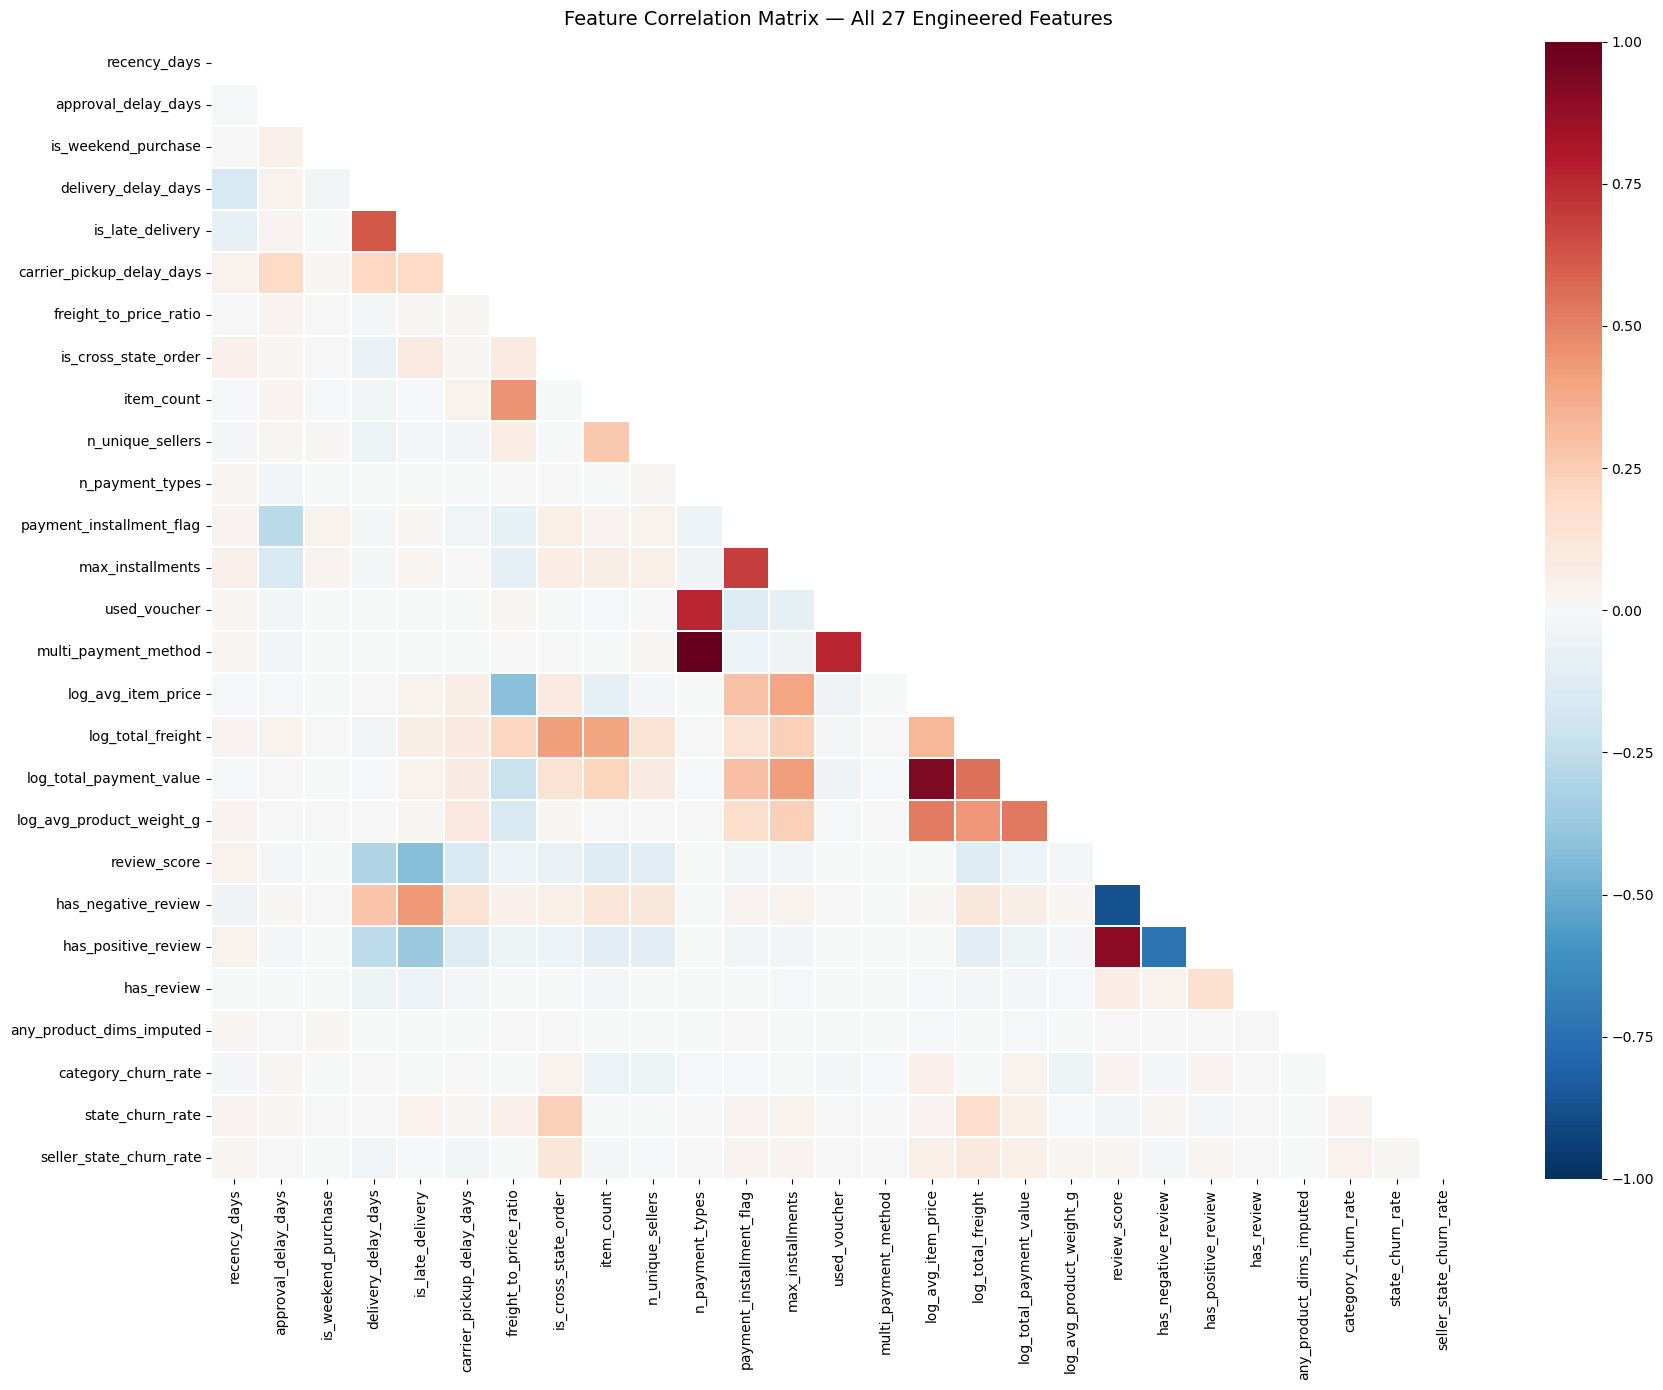

In [21]:
# Heatmap of full correlation matrix
fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    ax=ax
)
ax.set_title('Feature Correlation Matrix — All 27 Engineered Features', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

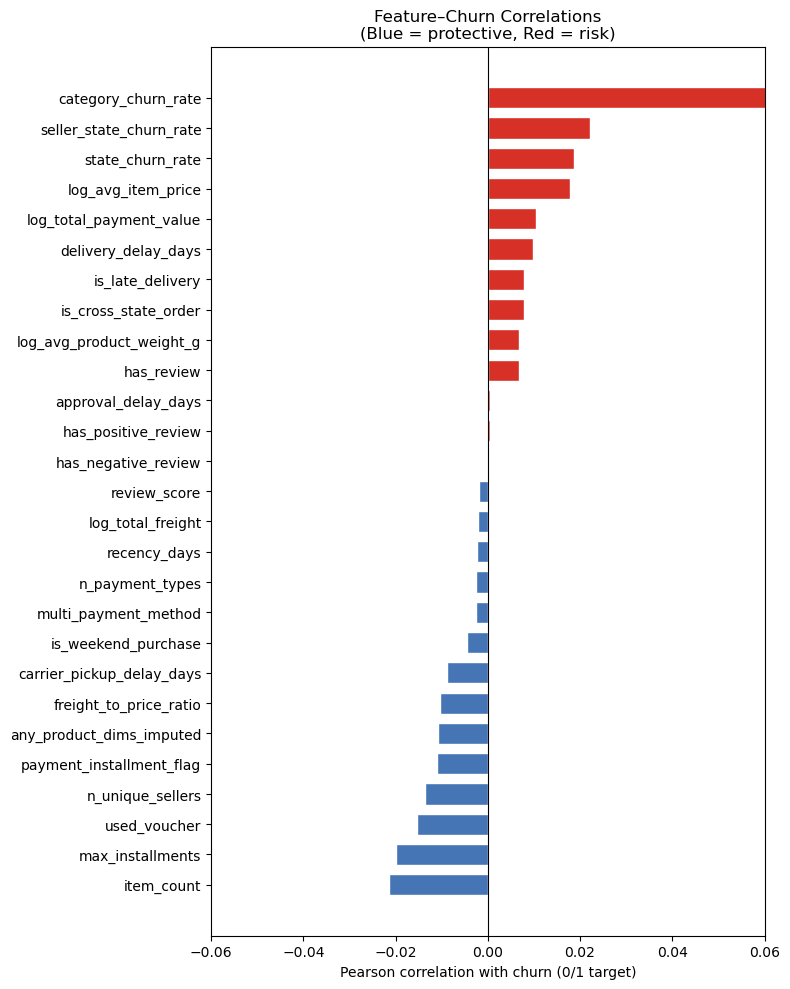


Top protective features (negative correlation → less churn):
item_count                 -0.0214
max_installments           -0.0199
used_voucher               -0.0153
n_unique_sellers           -0.0137
payment_installment_flag   -0.0110
Name: churn, dtype: float64

Top risk features (positive correlation → more churn):
log_total_payment_value   0.0105
log_avg_item_price        0.0178
state_churn_rate          0.0187
seller_state_churn_rate   0.0221
category_churn_rate       0.0712
Name: churn, dtype: float64


In [22]:
# Point-biserial correlation of each feature with the churn target
# (simple Pearson on the 0/1 target is equivalent for binary targets)
churn_corr = features[feature_cols + ['churn']].corr()['churn'].drop('churn').sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#d73027' if v > 0 else '#4575b4' for v in churn_corr.values]
ax.barh(churn_corr.index, churn_corr.values, color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with churn (0/1 target)')
ax.set_title('Feature–Churn Correlations\n(Blue = protective, Red = risk)', fontsize=12)
ax.set_xlim(-0.06, 0.06)
plt.tight_layout()
plt.show()

print('\nTop protective features (negative correlation → less churn):')
print(churn_corr.head(5))
print('\nTop risk features (positive correlation → more churn):')
print(churn_corr.tail(5))

**Interpretation:** As expected from NB03, all feature–churn correlations are small (all |r| < 0.05) due to the 97.82% class imbalance compressing the variance in the target. The rankings should be consistent with what NB03 found:
- **Most protective**: `item_count`, `max_installments`, `used_voucher` (negative correlation → associated with lower churn)
- **Most risky**: `log_avg_item_price`, `log_total_payment_value`, `recency_days` (positive correlation)

These small correlations do not mean the features are useless — tree-based models can extract interaction signals that linear correlation analysis misses. The correlations set the floor expectation; NB06 SHAP will reveal the full picture.

---

## 13. Collinearity Resolution for Logistic Regression

The confirmed high-correlation pair from NB03 is `total_payment_value` ↔ `avg_item_price` (r = 0.919), now appearing as `log_total_payment_value` ↔ `log_avg_item_price` in log-transformed form.

In [23]:
# Verify the known collinear pair in the engineered feature space
r_known = features['log_total_payment_value'].corr(features['log_avg_item_price'])
print(f'log_total_payment_value ↔ log_avg_item_price: r = {r_known:.4f}')
print(f'\nCollinearity resolution decision:')
print('  Tree-based models (LightGBM, Random Forest): include BOTH features.')
print('  Logistic Regression (NB05 baseline): DROP log_total_payment_value, keep log_avg_item_price.')
print('  This will be implemented in NB05 via separate feature lists per model — NOT by dropping here.')

log_total_payment_value ↔ log_avg_item_price: r = 0.9344

Collinearity resolution decision:
  Tree-based models (LightGBM, Random Forest): include BOTH features.
  Logistic Regression (NB05 baseline): DROP log_total_payment_value, keep log_avg_item_price.
  This will be implemented in NB05 via separate feature lists per model — NOT by dropping here.


**Interpretation:** The log transformation slightly reduces but does not eliminate the collinearity. For tree-based models, including both is safe — gradient boosting assigns each feature to different split conditions and handles redundancy gracefully. For Logistic Regression, the inflated variance from collinear predictors would make coefficients unreliable. The fix is implemented in NB05 by defining model-specific feature lists.

---

## 14. Export

In [24]:
# Final validation before export
print('=== FINAL VALIDATION ===')
print(f'Shape:         {features.shape}  (expected: (74899, {len(CANONICAL_COLUMNS)}))')
print(f'Total nulls:   {features.isnull().sum().sum()}  (expected: 0)')
print(f'Churn rate:    {features["churn"].mean():.4f}  (expected: ~0.9782)')
print(f'Object cols:   {features.select_dtypes("object").columns.tolist()}  (expected: ["customer_unique_id"])')
print(f'Datetime cols: {features.select_dtypes("datetime64[ns]").columns.tolist()}  (expected: ["last_order_date"])')

assert features.shape == (74899, len(CANONICAL_COLUMNS))
assert features.isnull().sum().sum() == 0
assert abs(features['churn'].mean() - 0.9782) < 0.001

print('\n✅  All validation checks passed. Exporting...')

features.to_parquet('outputs/04_features.parquet', index=False)
print('✅  Exported: outputs/04_features.parquet')

=== FINAL VALIDATION ===
Shape:         (74899, 30)  (expected: (74899, 30))
Total nulls:   0  (expected: 0)
Churn rate:    0.9782  (expected: ~0.9782)
Object cols:   ['customer_unique_id']  (expected: ["customer_unique_id"])
Datetime cols: ['last_order_date']  (expected: ["last_order_date"])

✅  All validation checks passed. Exporting...
✅  Exported: outputs/04_features.parquet


In [25]:
# Verify the exported file can be loaded and matches the in-memory version
verify = pd.read_parquet('outputs/04_features.parquet')
assert verify.shape == features.shape
assert list(verify.columns) == list(features.columns)
print(f'✅  Export verified: {verify.shape[0]:,} rows × {verify.shape[1]} columns loaded successfully.')

✅  Export verified: 74,899 rows × 30 columns loaded successfully.


---

## 15. Notebook Summary

### What was accomplished

NB04 transformed the raw master table (74,899 rows × 28 columns) into a modelling-ready feature matrix (74,899 rows × 29 columns) with 27 engineered features, all grounded in confirmed EDA signal from NB03.

### Features engineered (27 total)

| Group | Features | Count |
|---|---|---|
| Temporal | `recency_days`, `approval_delay_days`, `is_weekend_purchase` | 3 |
| Delivery experience | `delivery_delay_days`, `is_late_delivery`, `carrier_pickup_delay_days`, `freight_to_price_ratio`, `is_cross_state_order` | 5 |
| Order complexity | `item_count`, `n_unique_sellers`, `n_payment_types`, `payment_installment_flag`, `max_installments`, `used_voucher`, `multi_payment_method` | 7 |
| Monetary | `log_avg_item_price`, `log_total_freight`, `log_total_payment_value`, `log_avg_product_weight_g` | 4 |
| Review | `review_score`, `has_negative_review`, `has_positive_review`, `has_review` | 4 |
| Product | `any_product_dims_imputed`, `category_churn_rate` | 2 |
| Geographic | `state_churn_rate`, `seller_state_churn_rate` | 2 |

### Key decisions documented

1. **Log1p transformation** applied to all monetary features — compresses right-tail outliers without Winsorisation.
2. **Target encoding** used for `product_category_name_english` and `customer_state`/`seller_state` — collapses high-cardinality categoricals to a single numeric churn-rate signal.
3. **Leakage caveat**: both target encodings use the full dataset. NB05 must recompute them on training data only within a pipeline.
4. **Collinearity resolution**: `log_total_payment_value` and `log_avg_item_price` (r ≈ 0.919) both kept in the feature matrix. NB05 will drop `log_total_payment_value` for the Logistic Regression baseline only.
5. **Review score nulls**: filled with median 3.0 (646 rows, 0.72%) — documented and justified.
6. **Zero nulls** in final feature matrix — validated by hard assert.

### What NB05 will receive

- `outputs/04_features.parquet` — 74,899 rows × 29 columns (27 features + `churn` target + `customer_unique_id` + `last_order_date`)
- `last_order_date` is the time-based split key: NB05 trains on `last_order_date < 2018-06-01`, tests on `last_order_date >= 2018-06-01`.
- `customer_unique_id` is for traceability only — must not be included as a model feature.
- **Two leakage warnings** must be resolved in NB05: `category_churn_rate` and `state_churn_rate`/`seller_state_churn_rate` must be recomputed on training data only.